**Anomaly Detection & Time Series**

**Question 1**:  What is Anomaly Detection? Explain its types (point, contextual, and
collective anomalies) with examples.

## Answer

**Anomaly Detection** is the process of identifying data points or patterns that significantly differ from normal behavior. These unusual observations are called **anomalies** or **outliers**. It is widely used in fraud detection, network security, medical diagnosis, and fault detection.

### Types of Anomalies

### 1. Point Anomaly
A **point anomaly** is a single data point that is significantly different from the rest of the data.

**Example:**
- In a bank account where daily transactions are between ₹500 and ₹5,000, a transaction of ₹5,00,000 is a point anomaly.

### 2. Contextual Anomaly
A **contextual anomaly** occurs when a data point is abnormal only in a specific context, such as time or location.

**Example:**
- A temperature of **35°C** is normal in summer but abnormal during winter.

### 3. Collective Anomaly
A **collective anomaly** occurs when a group of related data points together forms an unusual pattern, even if each individual point appears normal.

**Example:**
- A sudden sequence of failed login attempts from the same IP address may indicate a cyber attack.

# Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.

## Answer

| Algorithm | Approach | Suitable Use Cases |
|-----------|----------|-------------------|
| **Isolation Forest** | Detects anomalies by randomly partitioning data. Anomalies require fewer splits to isolate. | Fraud detection, network intrusion detection, large datasets. |
| **DBSCAN** | Density-based clustering algorithm. Points not belonging to any dense cluster are treated as outliers. | Spatial data, clustering with noise, GPS/location data. |
| **Local Outlier Factor (LOF)** | Measures the local density of a point compared to its neighbors. Lower density indicates an anomaly. | Detecting local anomalies in datasets with varying densities, healthcare, finance. |

### Summary

- **Isolation Forest:** Fast and efficient for large datasets.
- **DBSCAN:** Best when clusters of arbitrary shapes exist and noise needs to be identified.
- **LOF:** Best for detecting local density-based anomalies.

---

# Question 3: What are the key components of a Time Series? Explain each with one example.

## Answer

A **Time Series** is a sequence of observations recorded at regular time intervals.

### Components of Time Series

### 1. Trend
The long-term upward or downward movement in data.

**Example:**
- Annual sales of an e-commerce company increasing every year.

### 2. Seasonality
Regular patterns that repeat at fixed intervals.

**Example:**
- Ice cream sales increase every summer.

### 3. Cyclical Component
Long-term fluctuations caused by economic or business cycles.

**Example:**
- Increase and decrease in automobile sales during economic booms and recessions.

### 4. Irregular (Random) Component
Unexpected variations that cannot be predicted.

**Example:**
- Sudden drop in airline bookings during a pandemic.

---

# Question 4: Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?

## Answer

A **stationary time series** is one whose statistical properties such as **mean, variance, and autocorrelation remain constant over time**.

### Characteristics of Stationary Data

- Constant mean
- Constant variance
- No trend or seasonality
- Constant autocorrelation

### Testing Stationarity

The most common statistical test is the **Augmented Dickey-Fuller (ADF) Test**.

- **Null Hypothesis (H₀):** The series is non-stationary.
- **Alternative Hypothesis (H₁):** The series is stationary.

**Decision Rule:**
- **p-value < 0.05:** Stationary
- **p-value ≥ 0.05:** Non-stationary

### Methods to Convert Non-Stationary Data into Stationary

1. **Differencing**
   - Subtract consecutive observations.
   - Example:
     ```
     Yt = Xt − Xt−1
     ```

2. **Log Transformation**
   - Reduces variance in the data.

3. **Moving Average**
   - Smooths short-term fluctuations.

4. **Seasonal Differencing**
   - Removes seasonal patterns.

---

# Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.

## Answer

| Model | Full Form | Structure | Application |
|--------|-----------|-----------|-------------|
| **AR** | AutoRegressive | Uses previous observations to predict future values. | Forecasting stationary time series with trend. |
| **MA** | Moving Average | Uses previous forecast errors to make predictions. | Removing random noise from stationary data. |
| **ARIMA** | AutoRegressive Integrated Moving Average | Combines AR, differencing (I), and MA. | Forecasting non-stationary time series after differencing. |
| **SARIMA** | Seasonal ARIMA | ARIMA with seasonal components. | Forecasting seasonal data such as monthly sales or weather. |
| **SARIMAX** | Seasonal ARIMA with Exogenous Variables | SARIMA plus external variables affecting the target variable. | Forecasting with seasonal patterns and additional influencing factors such as holidays, promotions, or weather. |

### Summary

- **AR:** Uses past values.
- **MA:** Uses past errors.
- **ARIMA:** AR + Differencing + MA.
- **SARIMA:** ARIMA with seasonal effects.
- **SARIMAX:** SARIMA with external (exogenous) variables.

# Question 6: Load a time series dataset (e.g., AirPassengers), plot the original series, and decompose it into trend, seasonality, and residual components.

## Answer

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from statsmodels.tsa.seasonal import seasonal_decompose


In [3]:
# Load AirPassengers dataset
data = get_rdataset("AirPassengers").data

# Create datetime index
data["Month"] = pd.date_range(start="1949-01", periods=len(data), freq="MS")
data.set_index("Month", inplace=True)

# Rename column
data.rename(columns={"value": "Passengers"}, inplace=True)

# Display first 5 rows
data.head()

,time,Passengers
Month,,
1949-01-01,1949.000000,112
1949-02-01,1949.083333,118
1949-03-01,1949.166667,132
1949-04-01,1949.250000,129
1949-05-01,1949.333333,121


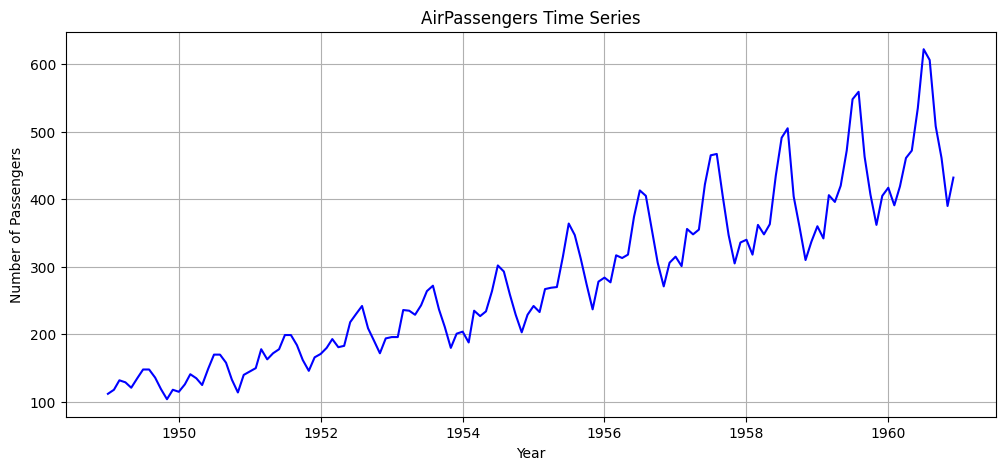

In [4]:
### Step 3: Plot the Original Time Series


plt.figure(figsize=(12,5))
plt.plot(data["Passengers"], color="blue")
plt.title("AirPassengers Time Series")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.grid(True)
plt.show()

In [7]:
### Step 4: Decompose the Time Series


decomposition = seasonal_decompose(
    data["Passengers"],
    model="multiplicative",
    period=12
)

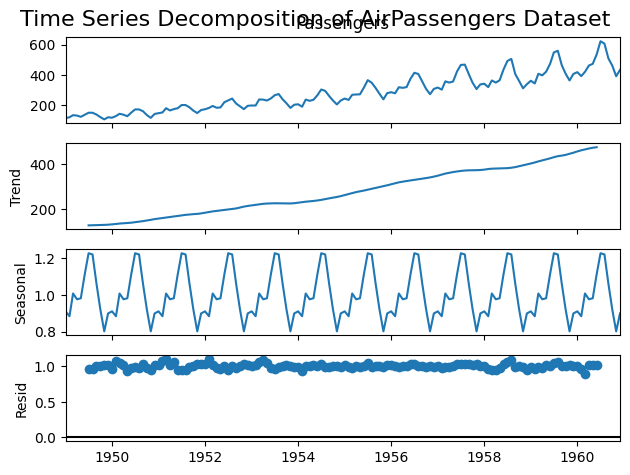

In [8]:
### Step 5: Plot Trend, Seasonality, and Residual Components


decomposition.plot()
plt.suptitle("Time Series Decomposition of AirPassengers Dataset", fontsize=16)
plt.show()

Output Components

### 1. Observed
- Displays the original AirPassengers time series.

### 2. Trend
- Shows the long-term increasing pattern in passenger numbers over the years.

### 3. Seasonal
- Shows the repeating yearly seasonal pattern (higher passenger traffic during certain months).

### 4. Residual (Random)
- Shows irregular variations remaining after removing trend and seasonality.

---


# Question 7: Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot.

## Answer

In [10]:
### Step 1: Import Required Libraries


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [13]:
### Step 2: Load the Dataset



# Load dataset
df = pd.read_csv("/content/NYC_taxi_fare_data.csv")

# Display first five rows
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238.0,239.0,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239.0,238.0,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238.0,238.0,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238.0,151.0,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193.0,193.0,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


In [14]:
### Step 3: Select Numerical Features


# Select two numerical features
X = df[["fare_amount", "trip_distance"]]

# Remove missing values
X = X.dropna()

Anomaly
 1    133446
-1      2706
Name: count, dtype: int64


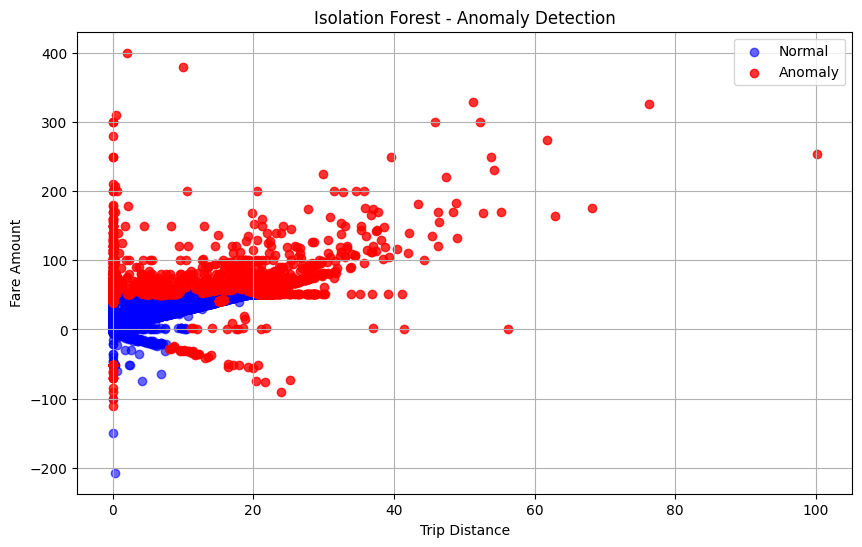

In [15]:
### Step 4: Train the Isolation Forest Model


model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

# Predict anomalies
X["Anomaly"] = model.fit_predict(X)

# Convert labels
# 1 = Normal
# -1 = Anomaly




### Step 5: Count Detected Anomalies


print(X["Anomaly"].value_counts())




### Step 6: Visualize Anomalies


plt.figure(figsize=(10,6))

# Normal points
plt.scatter(
    X[X["Anomaly"]==1]["trip_distance"],
    X[X["Anomaly"]==1]["fare_amount"],
    color="blue",
    label="Normal",
    alpha=0.6
)

# Anomalies
plt.scatter(
    X[X["Anomaly"]==-1]["trip_distance"],
    X[X["Anomaly"]==-1]["fare_amount"],
    color="red",
    label="Anomaly",
    alpha=0.8
)

plt.title("Isolation Forest - Anomaly Detection")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.legend()
plt.grid(True)

plt.show()

# Question 8: Train a SARIMA model on the monthly airline passengers dataset. Forecast the next 12 months and visualize the results.

## Answer

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.datasets import get_rdataset
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [18]:
# Load dataset
data = get_rdataset("AirPassengers").data

# Create Date column
data["Month"] = pd.date_range(start="1949-01", periods=len(data), freq="MS")

# Set index
data.set_index("Month", inplace=True)

# Rename column
data.rename(columns={"value": "Passengers"}, inplace=True)

# Display first 5 rows
data.head()

,time,Passengers
Month,,
1949-01-01,1949.000000,112
1949-02-01,1949.083333,118
1949-03-01,1949.166667,132
1949-04-01,1949.250000,129
1949-05-01,1949.333333,121


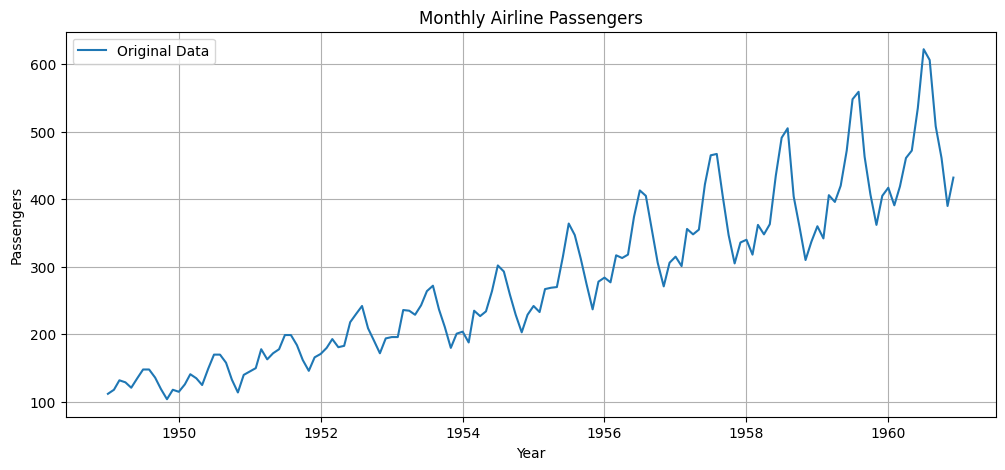

In [19]:
plt.figure(figsize=(12,5))
plt.plot(data["Passengers"], label="Original Data")
plt.title("Monthly Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# SARIMA(p,d,q)(P,D,Q,12)
model = SARIMAX(
    data["Passengers"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

results = model.fit()

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -506.149
Date:                            Fri, 26 Jun 2026   AIC                           1022.299
Time:                                    09:15:48   BIC                           1036.675
Sample:                                01-01-1949   HQIC                          1028.140
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1272      0.356     -0.358      0.721      -0.825       0.570
ma.L1         -0.2148      0.325   

In [21]:
forecast = results.get_forecast(steps=12)

forecast_values = forecast.predicted_mean
confidence_interval = forecast.conf_int()

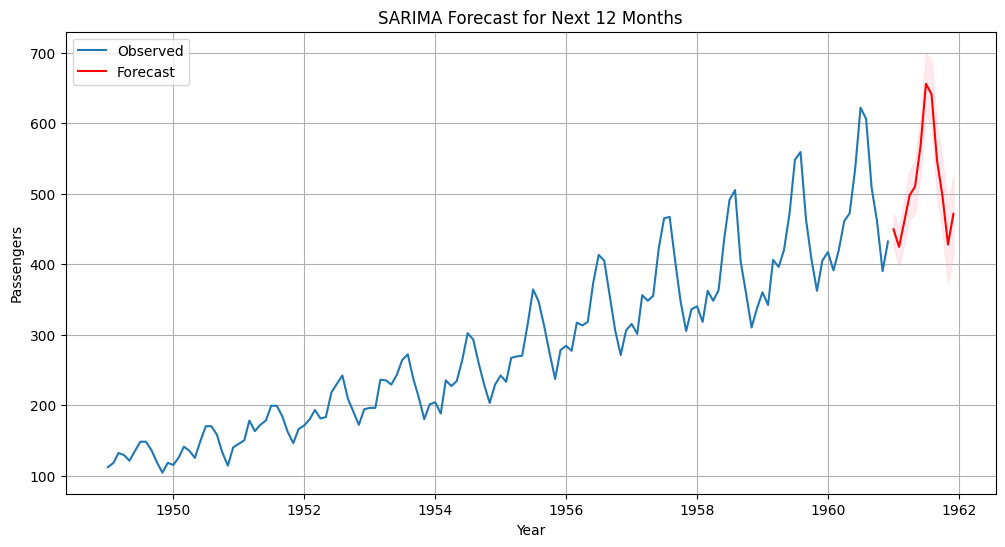

In [22]:
plt.figure(figsize=(12,6))

# Original data
plt.plot(data.index, data["Passengers"], label="Observed")

# Forecast
plt.plot(forecast_values.index,
         forecast_values,
         color="red",
         label="Forecast")

# Confidence Interval
plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    color="pink",
    alpha=0.3
)

plt.title("SARIMA Forecast for Next 12 Months")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)

plt.show()

In [23]:
forecast_df = pd.DataFrame({
    "Forecast": forecast_values
})

forecast_df

,Forecast
1961-01-01,449.330269
1961-02-01,424.386564
1961-03-01,459.033907
1961-04-01,497.865803
1961-05-01,509.863877
1961-06-01,568.258851
1961-07-01,655.811113
1961-08-01,641.191479
1961-09-01,546.393734
1961-10-01,496.801909


# Question 9: Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib.

## Answer


In [ ]:
### Step 1: Import Required Libraries


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor




### Step 2: Load the Dataset



# Load dataset
df = pd.read_csv("/content/NYC_taxi_fare_data.csv")

# Display first five rows
df.head()




### Step 3: Select Numerical Features


# Select two numerical columns
X = df[["fare_amount", "trip_distance"]]

# Remove missing values
X = X.dropna()




### Step 4: Apply Local Outlier Factor (LOF)

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

# Predict anomalies
X["Anomaly"] = lof.fit_predict(X)

# Labels:
# 1  = Normal
# -1 = Anomaly




### Step 5: Count the Detected Anomalies


print(X["Anomaly"].value_counts())




### Step 6: Visualize the Anomalies


plt.figure(figsize=(10,6))

# Plot normal observations
plt.scatter(
    X[X["Anomaly"] == 1]["trip_distance"],
    X[X["Anomaly"] == 1]["fare_amount"],
    color="blue",
    alpha=0.6,
    label="Normal"
)

# Plot anomalies
plt.scatter(
    X[X["Anomaly"] == -1]["trip_distance"],
    X[X["Anomaly"] == -1]["fare_amount"],
    color="red",
    alpha=0.8,
    label="Anomaly"
)

plt.title("Local Outlier Factor (LOF) - Anomaly Detection")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.legend()
plt.grid(True)

plt.show()

# Question 10

## Scenario

You are working as a **Data Scientist** for a power grid monitoring company. The objective is to **forecast short-term energy demand** and **detect abnormal spikes or drops** in electricity consumption collected every **15 minutes**. The dataset contains **timestamp, region, weather conditions, and energy usage**.

---

# Answer

## 1. Real-Time Data Science Workflow

### Step 1: Data Collection
- Collect real-time energy usage data every 15 minutes from smart meters.
- Gather additional information such as:
  - Timestamp
  - Region
  - Temperature
  - Humidity
  - Weather conditions
  - Holiday information

---

### Step 2: Data Preprocessing
- Remove duplicate records.
- Handle missing values.
- Convert timestamps into datetime format.
- Create useful features such as:
  - Hour of day
  - Day of week
  - Month
  - Weekend/Holiday indicator

---

### Step 3: Anomaly Detection

For streaming energy data, I would use **Isolation Forest**.

**Reason:**
- Works well on large datasets.
- Detects anomalies quickly.
- Does not require labeled data.
- Suitable for real-time processing.

**Examples of anomalies:**
- Sudden increase in electricity demand.
- Unexpected drop due to equipment failure.
- Sensor malfunction.
- Power theft or faulty meter readings.

---

### Step 4: Short-Term Forecasting

I would use the **SARIMAX (Seasonal ARIMA with Exogenous Variables)** model.

**Reason:**
- Captures trend and seasonality.
- Uses external variables such as:
  - Temperature
  - Weather conditions
  - Holidays
  - Region

This provides more accurate short-term energy demand forecasts than ARIMA or SARIMA alone.

---

### Step 5: Generate Forecasts

- Predict electricity demand for the next:
  - 15 minutes
  - 1 hour
  - 24 hours

- Continuously update the forecast as new data arrives.

---

### Step 6: Visualization & Alerts

Create a monitoring dashboard showing:
- Live energy consumption
- Forecasted demand
- Detected anomalies
- Alert notifications for abnormal spikes or drops

---

# 2. Detecting Anomalies in Streaming Data

### Isolation Forest
- Best choice for real-time anomaly detection.
- Fast and scalable.
- Detects unusual consumption patterns efficiently.

### Local Outlier Factor (LOF)
- Detects anomalies based on local density.
- Better for smaller datasets with varying densities.
- Less suitable for high-speed streaming data.

### DBSCAN
- Groups similar observations into clusters.
- Points outside clusters are treated as anomalies.
- Suitable for offline analysis but slower for continuous streaming.

**Best Choice:** **Isolation Forest**

---

# 3. Time Series Model for Forecasting

| Model | Advantages | Suitable |
|--------|------------|----------|
| **ARIMA** | Handles non-seasonal time series | No |
| **SARIMA** | Captures seasonal patterns | Good |
| **SARIMAX** | Captures seasonality and uses external variables (weather, holidays, region) | **Best Choice** |

**Selected Model:** **SARIMAX**

---

# 4. Validation and Performance Monitoring

### Model Validation

Split the data into:
- Training set (80%)
- Testing set (20%)

Evaluate forecasting accuracy using:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

---

### Continuous Monitoring

- Compare predicted demand with actual demand.
- Monitor forecasting errors over time.
- Retrain the model periodically using the latest data.
- Monitor anomaly detection accuracy by reviewing detected abnormal events.

---

# 5. Business Benefits

The proposed solution helps the power grid company by:

- Predicting electricity demand in advance.
- Detecting abnormal power consumption instantly.
- Preventing power outages.
- Identifying equipment failures early.
- Supporting efficient load balancing.
- Reducing operational costs.
- Improving grid reliability and customer satisfaction.
- Assisting operators in making quick, data-driven decisions during peak demand periods.

---

# Conclusion

A real-time energy monitoring system using **Isolation Forest** for anomaly detection and **SARIMAX** for short-term forecasting provides accurate demand predictions and rapid detection of abnormal energy usage. Continuous validation and monitoring ensure reliable performance, helping the power grid company optimize operations, reduce costs, and maintain a stable electricity supply.